📂 Arşiv çıkarılıyor... (Lütfen bekleyin)
✅ Çıkarma işlemi tamam!
🚀 Çalışılan Cihaz: cuda
Sınıflar: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Eğitim Seti: 28709 | Test Seti: 7178

🔥 ResNeXt-50 Modeli Yükleniyor...
Downloading: "https://download.pytorch.org/models/resnext50_32x4d-7cdf4587.pth" to /root/.cache/torch/hub/checkpoints/resnext50_32x4d-7cdf4587.pth


100%|██████████| 95.8M/95.8M [00:00<00:00, 133MB/s]


Eğitim Başlıyor... (Toplam 10 Epoch)
Epoch 1/10 | Süre: 8.1 dk | Loss: 1.1202 | Acc: 0.6400
Epoch 2/10 | Süre: 8.2 dk | Loss: 0.9171 | Acc: 0.6581
Epoch 3/10 | Süre: 8.2 dk | Loss: 0.8181 | Acc: 0.6719
Epoch 4/10 | Süre: 8.2 dk | Loss: 0.7412 | Acc: 0.6799
Epoch 5/10 | Süre: 8.2 dk | Loss: 0.6623 | Acc: 0.6797
Epoch 6/10 | Süre: 8.2 dk | Loss: 0.5726 | Acc: 0.6885
Epoch 7/10 | Süre: 8.2 dk | Loss: 0.5015 | Acc: 0.6867
Epoch 8/10 | Süre: 8.2 dk | Loss: 0.4265 | Acc: 0.6914
Epoch 9/10 | Süre: 8.2 dk | Loss: 0.3683 | Acc: 0.6909
Epoch 10/10 | Süre: 8.2 dk | Loss: 0.3172 | Acc: 0.6914

✅ ResNeXt Eğitimi Tamamlandı! Toplam Süre: 82.3 dakika
✅ Model Colab içine kaydedildi: resnext50_duygu_modeli.pth


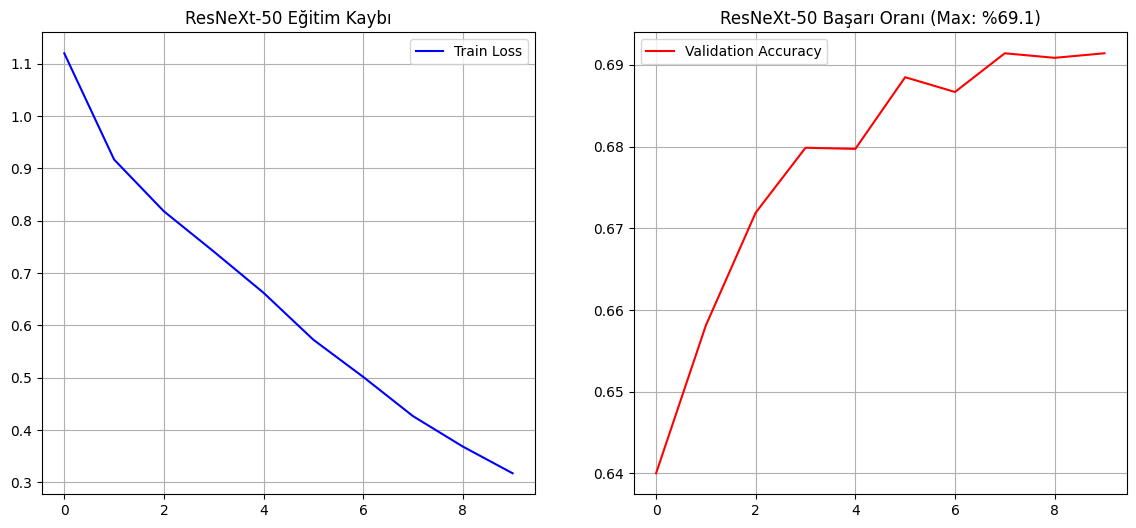

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import pandas as pd
import os
import time
import zipfile


if not os.path.exists('train') and os.path.exists('archive.zip'):
    print("📂 Arşiv çıkarılıyor... (Lütfen bekleyin)")
    with zipfile.ZipFile('archive.zip', 'r') as zip_ref:
        zip_ref.extractall('.')
    print("✅ Çıkarma işlemi tamam!")


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 Çalışılan Cihaz: {device}")


BATCH_SIZE = 32
LEARNING_RATE = 0.0001
EPOCHS = 10
NUM_CLASSES = 7
DATA_DIR = '.'
IMDB_PATH = 'imdb_top_1000.csv'

 
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.Grayscale(num_output_channels=3),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(15),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'test': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.Grayscale(num_output_channels=3),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

if os.path.exists(os.path.join(DATA_DIR, 'train')):
    image_datasets = {x: datasets.ImageFolder(os.path.join(DATA_DIR, x), data_transforms[x])
                      for x in ['train', 'test']}
    dataloaders = {x: DataLoader(image_datasets[x], batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
                   for x in ['train', 'test']}
    class_names = image_datasets['train'].classes
    dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'test']}
    print(f"Sınıflar: {class_names}")
    print(f"Eğitim Seti: {dataset_sizes['train']} | Test Seti: {dataset_sizes['test']}")
else:
    print("❌ HATA: Klasörler bulunamadı. Zip dosyası yüklü mü?")

# --- 3. MODEL: ResNeXt-50 ---
print("\n🔥 ResNeXt-50 Modeli Yükleniyor...")
model = models.resnext50_32x4d(weights=models.ResNeXt50_32X4D_Weights.IMAGENET1K_V1)

# Son katmanı 7 duygu sınıfına göre ayarlıyoruz
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, NUM_CLASSES)
model = model.to(device)

# --- 4. EĞİTİM DÖNGÜSÜ ---
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

train_loss_hist = []
val_acc_hist = []

print(f"Eğitim Başlıyor... (Toplam {EPOCHS} Epoch)")
start_time = time.time()

for epoch in range(EPOCHS):
    epoch_start = time.time()

    # Train
    model.train()
    running_loss = 0.0
    for inputs, labels in dataloaders['train']:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)

    epoch_loss = running_loss / dataset_sizes['train']
    train_loss_hist.append(epoch_loss)

    # Validation
    model.eval()
    running_corrects = 0
    with torch.no_grad():
        for inputs, labels in dataloaders['test']:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            running_corrects += torch.sum(preds == labels.data)

    epoch_acc = running_corrects.double() / dataset_sizes['test']
    val_acc_hist.append(epoch_acc.item())

    epoch_end = time.time()
    duration = (epoch_end - epoch_start) / 60
    print(f'Epoch {epoch+1}/{EPOCHS} | Süre: {duration:.1f} dk | Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.4f}')

total_time = time.time() - start_time
print(f"\n✅ ResNeXt Eğitimi Tamamlandı! Toplam Süre: {total_time/60:.1f} dakika")


torch.save(model.state_dict(), 'resnext50_duygu_modeli.pth')
print("✅ Model Colab içine kaydedildi: resnext50_duygu_modeli.pth")


plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.plot(train_loss_hist, label='Train Loss', color='blue')
plt.title('ResNeXt-50 Eğitim Kaybı')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(val_acc_hist, label='Validation Accuracy', color='red')
plt.title(f'ResNeXt-50 Başarı Oranı (Max: %{max(val_acc_hist)*100:.1f})')
plt.legend()
plt.grid(True)
plt.show()


def recommend_movies(emotion):
    genre_map = {
        'angry': 'Action', 'disgust': 'Horror', 'fear': 'Comedy',
        'happy': 'Romance', 'neutral': 'Sci-Fi', 'sad': 'Animation', 'surprise': 'Mystery'
    }
    target_genre = genre_map.get(emotion, 'Drama')

    if os.path.exists(IMDB_PATH):
        df = pd.read_csv(IMDB_PATH)
        filtered = df[df['Genre'].str.contains(target_genre, case=False, na=False)]
        if not filtered.empty:
            suggestions = filtered.sample(n=3)[['Series_Title', 'Genre', 'IMDB_Rating']]
            print(f"\n🎬 DUYGU: {emotion.upper()} -> TÜR: {target_genre}")
            for i, row in suggestions.iterrows():
                print(f"⭐ {row['Series_Title']} ({row['IMDB_Rating']})")
    else:
        print("IMDB dosyası bulunamadı!")

# Rastgele bir test
model.eval()
try:
    test_loader_iter = iter(dataloaders['test'])
    test_images, test_labels = next(test_loader_iter)
    img = test_images[0].to(device)
    with torch.no_grad():
        output = model(img.unsqueeze(0))
        _, pred = torch.max(output, 1)
        pred_emotion = class_names[pred.item()]

    
    img_cpu = test_images[0].permute(1, 2, 0).numpy() * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406]
    plt.imshow(np.clip(img_cpu, 0, 1))
    plt.title(f"ResNeXt Tahmini: {pred_emotion}")
    plt.axis('off')
    plt.show()
    recommend_movies(pred_emotion)
except:
    pass

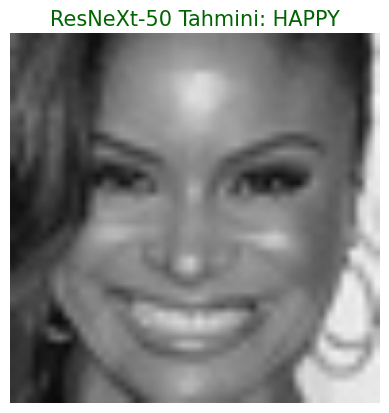


🎬 DUYGU: HAPPY -> TÜR: Romance
⭐ Bin-jip (8.0)
⭐ Hana-bi (7.8)
⭐ Cast Away (7.8)


In [ ]:
import numpy as np

model.eval()

try:
    
    test_loader_iter = iter(dataloaders['test'])
    images, labels = next(test_loader_iter)

    # İlk resmi seç ve modele gönder
    img = images[0].unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(img)
        _, pred = torch.max(output, 1)
        pred_emotion = class_names[pred.item()]

    
    img_display = images[0].permute(1, 2, 0).numpy()
    # Normalizasyonu geri al 
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img_display = std * img_display + mean
    img_display = np.clip(img_display, 0, 1)

    plt.imshow(img_display)
    plt.title(f"ResNeXt-50 Tahmini: {pred_emotion.upper()}", fontsize=15, color='darkgreen')
    plt.axis('off')
    plt.show()

    recommend_movies(pred_emotion)

except Exception as e:
    print(f"Öneri sırasında bir hata oluştu: {e}")

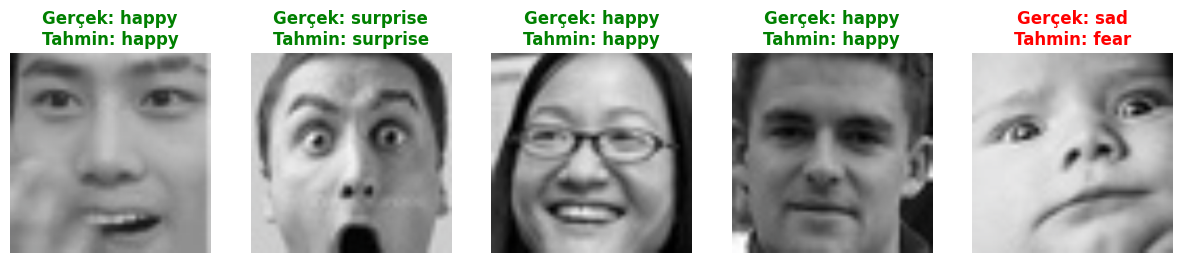

In [ ]:
def check_true_vs_pred(model, num_images=5):
    model.eval()
    images_so_far = 0
    plt.figure(figsize=(15, 10))

    with torch.no_grad():
        for i, (inputs, labels) in enumerate(dataloaders['test']):
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            for j in range(inputs.size()[0]):
                images_so_far += 1
                ax = plt.subplot(1, num_images, images_so_far)
                ax.axis('off')

                # Resmi gösterim için hazırla
                img = inputs.cpu().data[j].numpy().transpose((1, 2, 0))
                mean = np.array([0.485, 0.456, 0.406])
                std = np.array([0.229, 0.224, 0.225])
                img = std * img + mean
                img = np.clip(img, 0, 1)
                plt.imshow(img)

                true_label = class_names[labels[j]]
                pred_label = class_names[preds[j]]

                color = 'green' if true_label == pred_label else 'red'
                ax.set_title(f"Gerçek: {true_label}\nTahmin: {pred_label}", color=color, fontweight='bold')

                if images_so_far == num_images:
                    return

check_true_vs_pred(model)

In [1]:
!unzip -q archive.zip

In [ ]:

import os
import torch
import torch.nn as nn
from torchvision import models, transforms, datasets
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize


DATA_DIR = '.'
BATCH_SIZE = 32


data_transforms = {
    'test': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.Grayscale(num_output_channels=3),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}


if os.path.exists(os.path.join(DATA_DIR, 'test')):
    image_datasets = {'test': datasets.ImageFolder(os.path.join(DATA_DIR, 'test'), data_transforms['test'])}
    dataloaders = {'test': DataLoader(image_datasets['test'], batch_size=BATCH_SIZE, shuffle=False)}
    class_names = image_datasets['test'].classes
    print(f"✅ Test verileri başarıyla yüklendi! Sınıflar: {class_names}")
    print(f"📊 Toplam Test Resmi: {len(image_datasets['test'])}")
else:
    print("❌ HATA: 'test' klasörü bulunamadı. Lütfen 'unzip' işleminin bittiğinden emin ol!")

✅ Test verileri başarıyla yüklendi! Sınıflar: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
📊 Toplam Test Resmi: 7178


In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:

model = models.resnext50_32x4d(weights=None)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 7)
model = model.to(device)


model.load_state_dict(torch.load('resnext50_duygu_modeli.pth', map_location=device))
model.eval()
print("✅ ResNeXt-50 Modeli Başarıyla Uyandırıldı!")

✅ ResNeXt-50 Modeli Başarıyla Uyandırıldı!


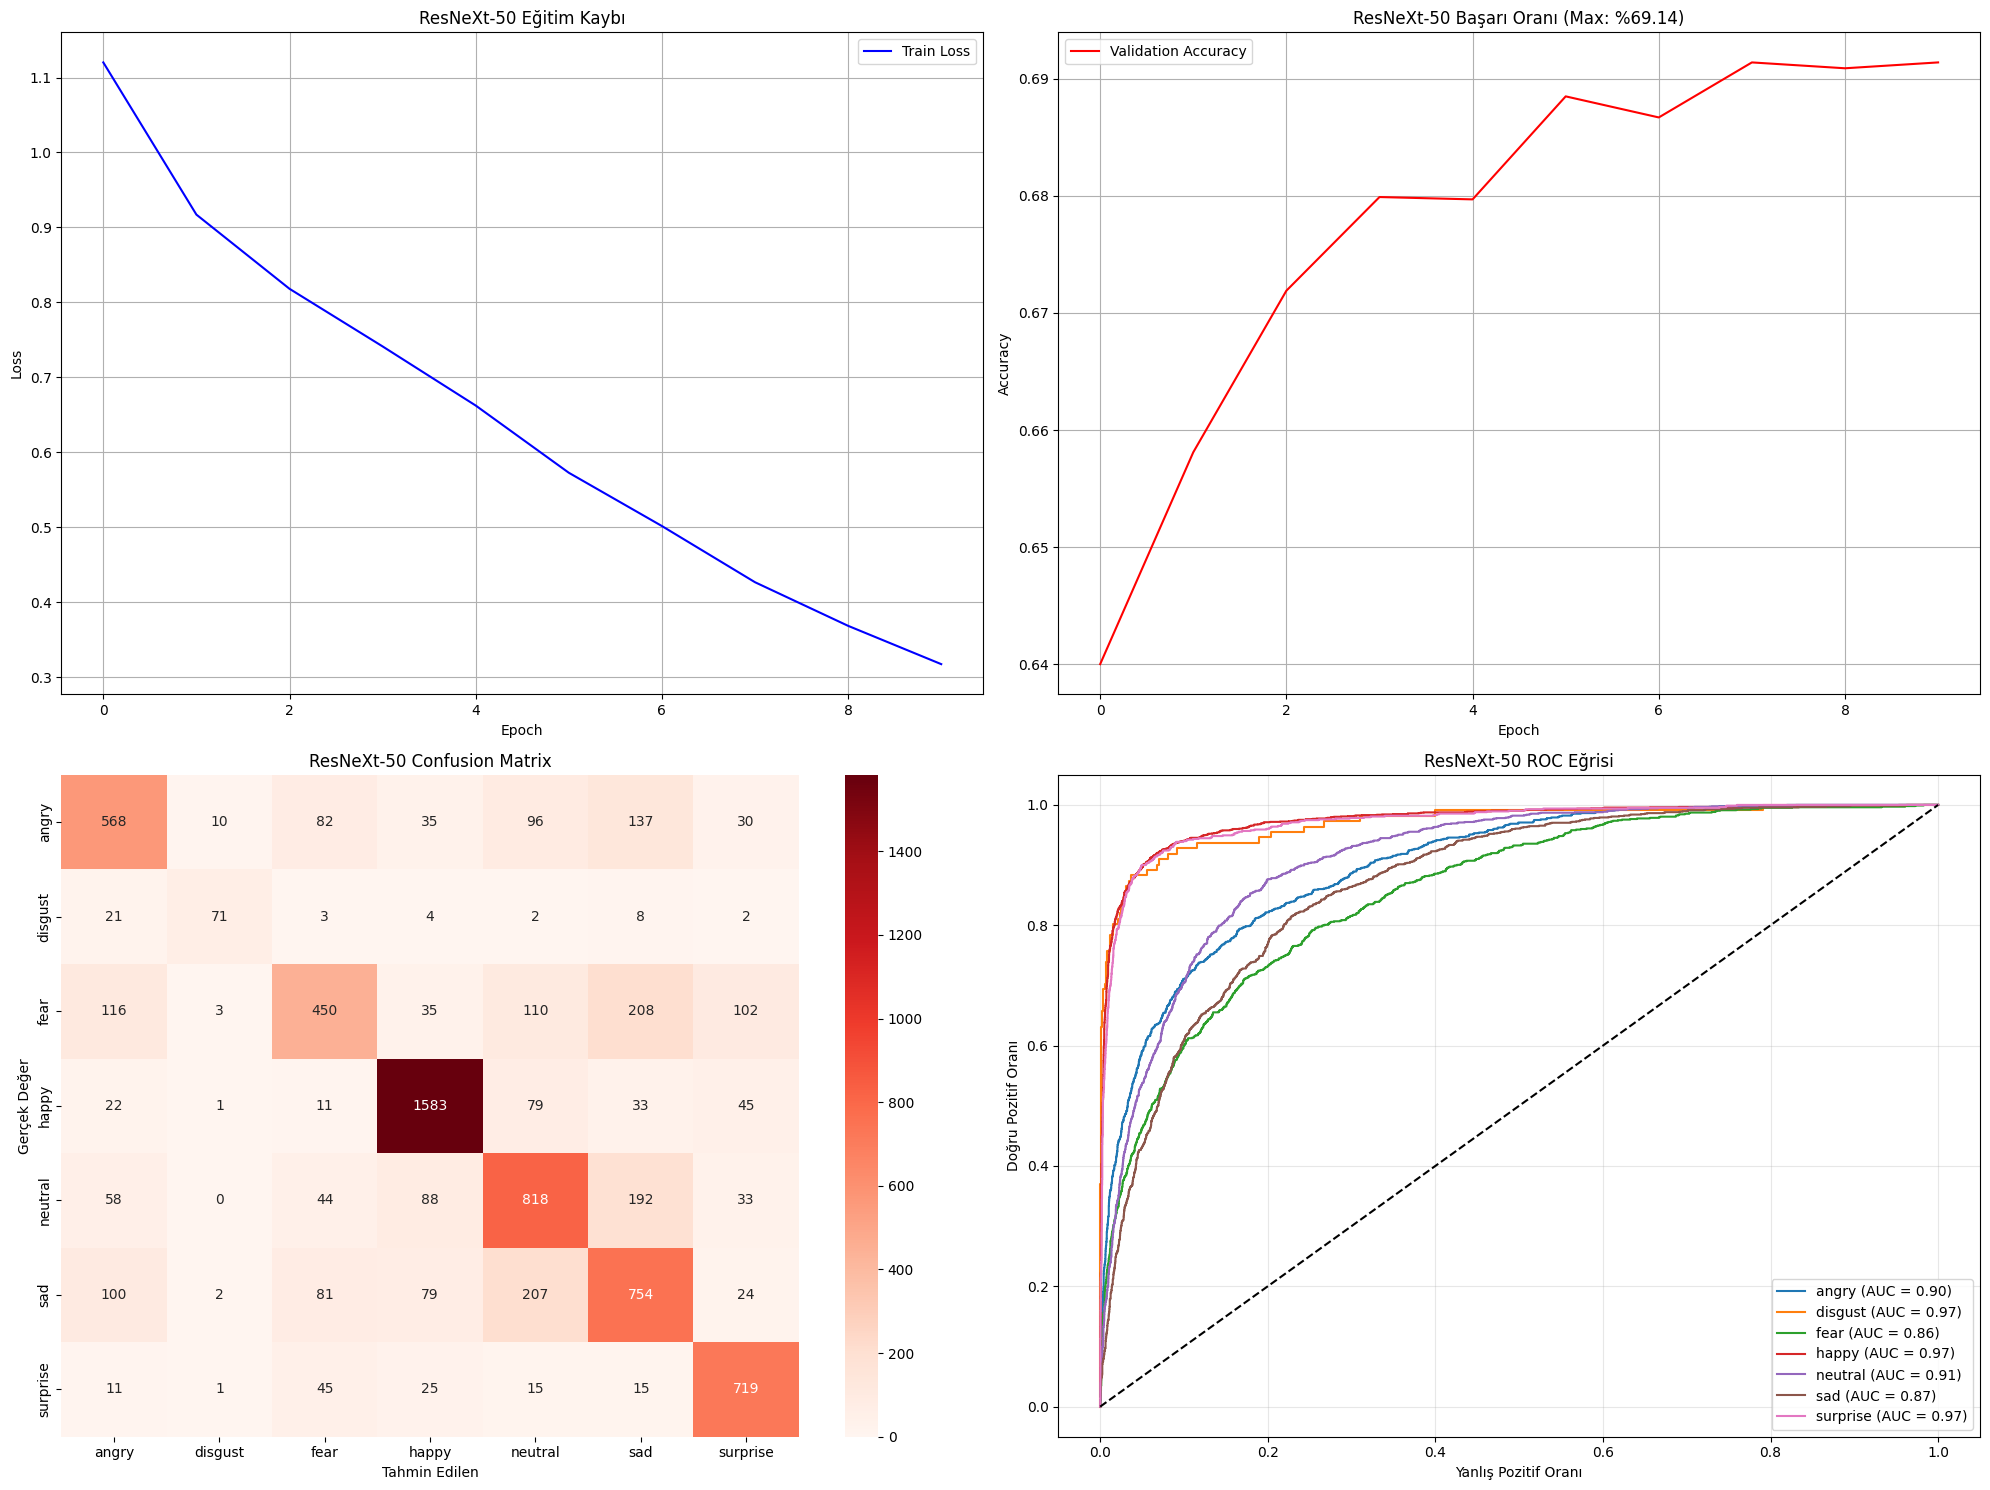

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
import numpy as np


train_loss_resnext = [1.1202, 0.9171, 0.8181, 0.7412, 0.6623, 0.5726, 0.5015, 0.4265, 0.3683, 0.3172]
val_acc_resnext = [0.6400, 0.6581, 0.6719, 0.6799, 0.6797, 0.6885, 0.6867, 0.6914, 0.6909, 0.6914]


plt.figure(figsize=(20, 15))


plt.subplot(2, 2, 1)
plt.plot(train_loss_resnext, label='Train Loss', color='blue')
plt.title('ResNeXt-50 Eğitim Kaybı')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)


plt.subplot(2, 2, 2)
plt.plot(val_acc_resnext, label='Validation Accuracy', color='red')
plt.title('ResNeXt-50 Başarı Oranı (Max: %69.14)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

all_preds = []
all_labels = []
model.eval()
with torch.no_grad():
    for inputs, labels in dataloaders['test']:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
plt.subplot(2, 2, 3)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Reds')
plt.xlabel('Tahmin Edilen')
plt.ylabel('Gerçek Değer')
plt.title('ResNeXt-50 Confusion Matrix')


y_test_bin = label_binarize(all_labels, classes=range(7))
all_probs = []
with torch.no_grad():
    for inputs, _ in dataloaders['test']:
        inputs = inputs.to(device)
        outputs = torch.softmax(model(inputs), dim=1)
        all_probs.extend(outputs.cpu().numpy())
all_probs = np.array(all_probs)

plt.subplot(2, 2, 4)
for i in range(7):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], all_probs[:, i])
    plt.plot(fpr, tpr, label=f'{class_names[i]} (AUC = {auc(fpr, tpr):.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('Yanlış Pozitif Oranı')
plt.ylabel('Doğru Pozitif Oranı')
plt.title('ResNeXt-50 ROC Eğrisi')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()